In [1]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("../data/20220412_adk_nadph_kinetics.csv", header=0)

In [3]:
df.head()

,Cycle Nr.,Time [s],Temp. [°C],B1,B2,B3,B4,B5,B6,B7,...,C9,C10,C11,C12,C13,C14,C15,C16,C17,C18
0,1,0.000,29.6,18319,14656,9035,8338,6063,6719,4912,...,2850,2806,2553,2820,2559,2763,2803,2636,3883,852
1,2,23.782,29.8,18571,14661,9049,8431,6089,6856,4908,...,2866,2856,2588,2867,2588,2800,2793,2625,3894,876
2,3,47.081,29.8,18444,14871,9116,8758,6191,6799,4996,...,2898,2899,2604,2871,2602,2792,2819,2623,3903,870
3,4,70.382,29.7,18620,14982,9354,8779,6292,6989,5013,...,2969,2898,2584,2861,2600,2773,2811,2625,3936,879
4,5,93.682,29.7,18739,15122,9440,8953,6348,7003,5067,...,2945,2917,2571,2905,2598,2807,2843,2650,3937,899


In [4]:
bs_df = df.iloc[:, 3:19].T

In [5]:
times = np.tile(df["Time [s]"], (16,1))

In [6]:
times

array([[   0.   ,   23.782,   47.081, ..., 7130.286, 7153.576, 7176.873],
       [   0.   ,   23.782,   47.081, ..., 7130.286, 7153.576, 7176.873],
       [   0.   ,   23.782,   47.081, ..., 7130.286, 7153.576, 7176.873],
       ...,
       [   0.   ,   23.782,   47.081, ..., 7130.286, 7153.576, 7176.873],
       [   0.   ,   23.782,   47.081, ..., 7130.286, 7153.576, 7176.873],
       [   0.   ,   23.782,   47.081, ..., 7130.286, 7153.576, 7176.873]])

In [7]:
bs_arr = np.array(bs_df)

Text(0, 0.5, 'RFU')

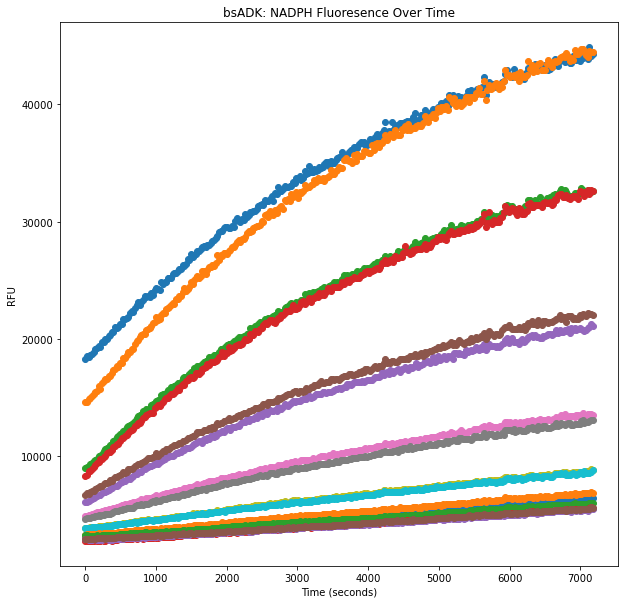

In [8]:
fig = plt.figure(figsize=(10,10))
for rfu, time in zip(np.array(bs_df), times):
    plt.scatter(time, rfu)
    
plt.title("bsADK: NADPH Fluoresence Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("RFU")

## Get Initial Rate

Text(0, 0.5, 'RFU')

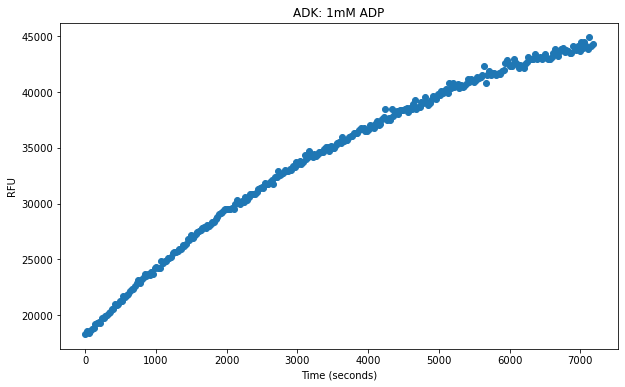

In [9]:
fig = plt.figure(figsize=(10,6))

plt.scatter(times[0], bs_arr[0])
plt.title("ADK: 1mM ADP")
plt.xlabel("Time (seconds)")
plt.ylabel("RFU")

## Trying "Gradient Descent Approach" To Initial Rate

In [10]:
def divide_chunks(l, n):
    n = math.ceil(len(l) / float(n))
    for i in range(0, len(l), n):
        yield l[i:i + n]

In [11]:
bs_high_conc = bs_arr[0] / 179
time_arr = times[0]

In [12]:
perc_bs_high_conc = list(divide_chunks(bs_high_conc, 100))
perc_times = list(divide_chunks(time_arr, 100))

In [13]:
r_2 = 0
threshold = 0.99
scores = []
slopes = [] 
intercepts = []
for i in range(len(perc_times), 0, -1):
    curr_times = [item for sublist in perc_times[:i] for item in sublist]
    curr_concs = [item for sublist in perc_bs_high_conc[:i] for item in sublist]
    reg = LinearRegression().fit(np.array(curr_times).reshape(-1,1), curr_concs)
    curr_score = reg.score(np.array(curr_times).reshape(-1,1), curr_concs)
    scores.append(curr_score)
    slopes.append(reg.coef_)
    intercepts.append(reg.intercept_)
    
    

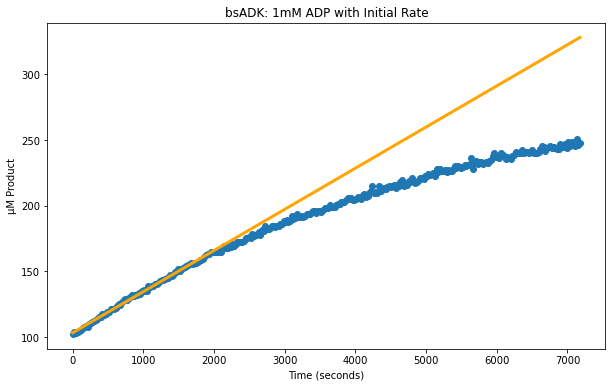

In [14]:
fig = plt.figure(figsize=(10,6))

plt.scatter(time_arr, bs_high_conc)
plt.title("bsADK: 1mM ADP with Initial Rate")
plt.xlabel("Time (seconds)")
plt.ylabel("µM Product")

x = np.linspace(min(time_arr), max(time_arr), 1000)
plt.plot(x, x*slopes[np.argmax(scores)] + intercepts[np.argmax(scores)] ,c="orange", linewidth=3)

## Wrapping Initial Slope into a Function

In [24]:
def compute_initial_reaction_slope(time_arr: np.array, 
                                   signal_arr: np.array): 
    
    perc_concs = list(divide_chunks(signal_arr, 100))
    perc_times = list(divide_chunks(time_arr, 100))
 
    scores = []
    slopes = [] 
    intercepts = []
    for i in range(len(perc_times), 0, -1):
        curr_times = [item for sublist in perc_times[:i] for item in sublist]
        curr_concs = [item for sublist in perc_concs[:i] for item in sublist]
        reg = LinearRegression().fit(np.array(curr_times).reshape(-1,1), curr_concs)
        curr_score = reg.score(np.array(curr_times).reshape(-1,1), curr_concs)
        scores.append(curr_score)
        slopes.append(reg.coef_)
        intercepts.append(reg.intercept_)
        
    max_r2_idx = np.argmax(scores)
    return slopes[max_r2_idx], intercepts[max_r2_idx], scores[max_r2_idx]

# Applying New Function to bsADK Data

In [16]:
sub_concs = [1000, 500, 250, 125, 62.5, 31.25, 15.625, 7.8125]

In [17]:
bs_rep_1_arr = bs_arr[0::2] / 179

In [18]:
print(len(list(zip(bs_rep_1_arr, sub_concs))))

8


In [19]:
bs_rep_1_arr.shape

(8, 309)

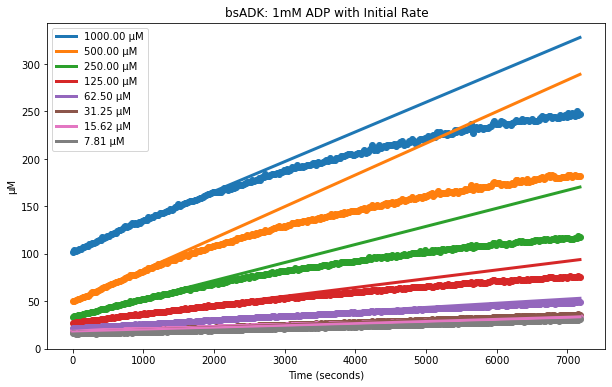

In [25]:
fig = plt.figure(figsize=(10,6))
    
for rep, sub_conc in zip(bs_rep_1_arr, sub_concs):
    slope, intercept, score = compute_initial_reaction_slope(time_arr, rep)
    plt.scatter(time_arr, rep)
    x = np.linspace(min(time_arr), max(time_arr), 1000)
    plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    
plt.title("bsADK: 1mM ADP with Initial Rate")
plt.xlabel("Time (seconds)")
plt.ylabel("µM")
plt.legend()

## Looking closer at initial rate fits

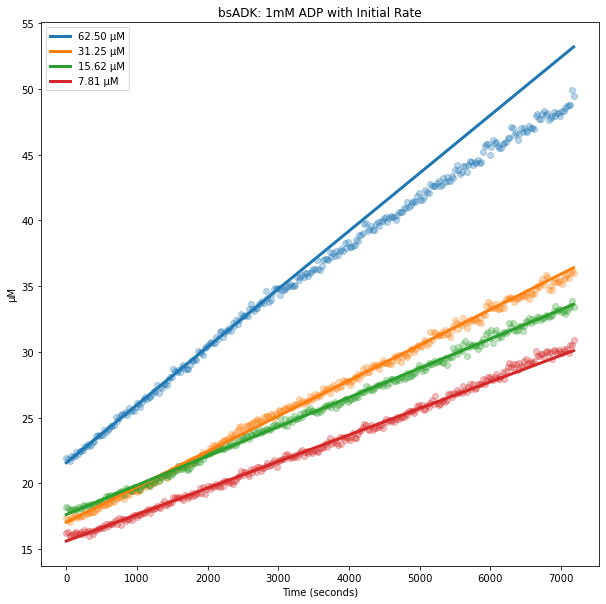

In [28]:
fig = plt.figure(figsize=(10,10))
    
for rep, sub_conc in zip(bs_rep_1_arr[4:], sub_concs[4:]):
    slope, intercept, score = compute_initial_reaction_slope(time_arr, rep)
    plt.scatter(time_arr, rep,alpha=0.3)
    x = np.linspace(min(time_arr), max(time_arr), 1000)
    plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    
plt.title("bsADK: 1mM ADP with Initial Rate")
plt.xlabel("Time (seconds)")
plt.ylabel("µM")
plt.legend()

^^^ This fitting method really falls apart at low substrate conc

# Micheaelis Menten for bsADK

In [29]:
bs_adk_rep_1_slopes = []
bs_adk_rep_2_slopes = []

for rep, sub_conc in zip(bs_arr[0::2] / 179, sub_concs):
    slope, _, _ = compute_initial_reaction_slope(time_arr, rep)
    bs_adk_rep_1_slopes.append(slope)

for rep, sub_conc in zip(bs_arr[1::2] / 179, sub_concs):
    slope, _, _ = compute_initial_reaction_slope(time_arr, rep)
    bs_adk_rep_2_slopes.append(slope)

In [30]:
bs_adk_avg_slopes = np.mean([bs_adk_rep_1_slopes, bs_adk_rep_2_slopes], axis=0)
errs = np.std([bs_adk_rep_1_slopes, bs_adk_rep_2_slopes], axis=0)

In [32]:
e_conc = .565 * 1e-4

Text(0, 0.5, 'v (µM/s)')

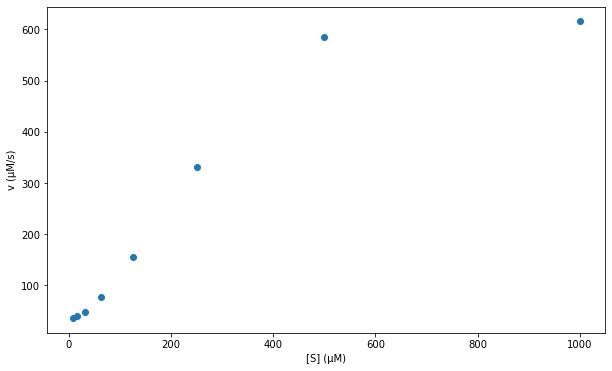

In [33]:
plt.figure(figsize=(10,6))
plt.scatter(sub_concs, np.array(bs_adk_avg_slopes) / e_conc)
plt.xlabel("[S] (µM)")
plt.ylabel("v (µM/s)")

In [34]:
def mm_model(x, v_max, Km):
    return v_max * x / (x + Km)

In [35]:
from scipy.optimize import curve_fit

In [37]:
print(bs_adk_avg_slopes)

[[0.03477867]
 [0.03307911]
 [0.01874049]
 [0.00879004]
 [0.00431528]
 [0.00275358]
 [0.00222206]
 [0.00205179]]


In [38]:
params, _ = curve_fit(mm_model, sub_concs, np.concatenate(bs_adk_avg_slopes))

Text(0, 0.5, 'v (µM/s)')

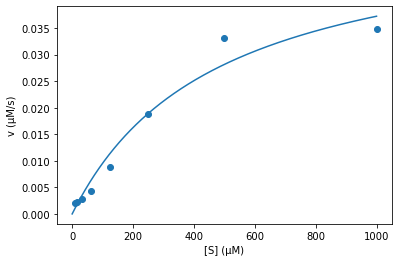

In [39]:
plt.scatter(sub_concs, bs_adk_avg_slopes)
x = np.linspace(0, 1000, 1000)
plt.plot(x, mm_model(x, params[0], params[1]))
plt.xlabel("[S] (µM)")
plt.ylabel("v (µM/s)")

In [40]:
params

array([5.49378222e-02, 4.75573297e+02])

In [41]:
params[0] / e_conc

972.3508360166131

# gsADK Plotting

In [42]:
gs_df = df.iloc[:, 21:37].T
gs_df

,0,1,2,3,4,5,6,7,8,9,...,299,300,301,302,303,304,305,306,307,308
C1,5885,5989,6075,6135,6234,6362,6410,6512,6671,6694,...,27814,28384,28237,28026,28002,27948,27733,28673,28154,28423
C2,6083,6179,6287,6302,6442,6598,6532,6631,6778,6898,...,26828,27416,27042,27085,27120,27121,26934,27190,27398,27331
C3,4542,4574,4723,4815,4846,4964,5025,5116,5290,5357,...,24021,24511,24283,24437,24516,24472,24495,24741,25024,24543
C4,4377,4540,4652,4716,4803,4978,4929,5093,5193,5223,...,23641,23849,23788,24018,23771,24078,23953,24195,24252,23858
C5,3637,3721,3737,3863,3947,4023,4055,4121,4218,4322,...,18994,19092,19060,19220,19045,19204,19078,19266,19235,19065
C6,3597,3642,3727,3810,3890,3938,3988,4051,4161,4127,...,18410,18624,18542,18292,18564,18405,18334,18495,18504,18581
C7,3186,3233,3282,3339,3384,3427,3509,3518,3578,3620,...,14465,14683,14548,14263,14371,14461,14348,14441,14506,14376
C8,3481,3642,3769,3947,4023,3955,4140,4083,4227,4030,...,13674,14134,13763,13928,13850,13919,13964,13781,13864,13779
C9,2850,2866,2898,2969,2945,2977,3069,3050,3077,3122,...,10063,9998,10078,9906,10018,10050,9913,10141,10138,10110
C10,2806,2856,2899,2898,2917,2952,2923,2938,2916,2960,...,9157,9087,9178,9110,9156,9041,9023,9371,9233,9235


In [43]:
gs_arr = np.array(gs_df)

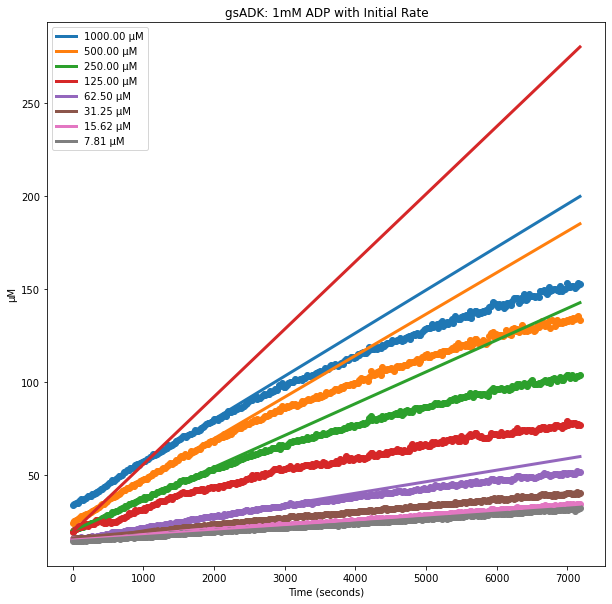

In [50]:
fig = plt.figure(figsize=(10,10))
    
for rep, sub_conc in zip(gs_arr[1::2] / 179, sub_concs):
    slope, intercept, score = compute_initial_reaction_slope(time_arr, rep)
    plt.scatter(time_arr, rep)
    x = np.linspace(min(time_arr), max(time_arr), 1000)
    plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    
plt.title("gsADK: 1mM ADP with Initial Rate")
plt.xlabel("Time (seconds)")
plt.ylabel("µM")
plt.legend()

In [45]:
gs_adk_rep_1_slopes = []
gs_adk_rep_2_slopes = []

for rep, sub_conc in zip(gs_arr[0::2] / 179, sub_concs):
    slope, _, _ = compute_initial_reaction_slope(time_arr, rep)
    gs_adk_rep_1_slopes.append(slope)

for rep, sub_conc in zip(gs_arr[1::2] / 179, sub_concs):
    slope, _, _ = compute_initial_reaction_slope(time_arr, rep)
    gs_adk_rep_2_slopes.append(slope)

In [46]:
gs_adk_avg_slopes = np.mean([gs_adk_rep_1_slopes, gs_adk_rep_2_slopes], axis=0)
errs = np.std([gs_adk_rep_1_slopes, gs_adk_rep_2_slopes], axis=0)

Text(0, 0.5, 'v (µM/s)')

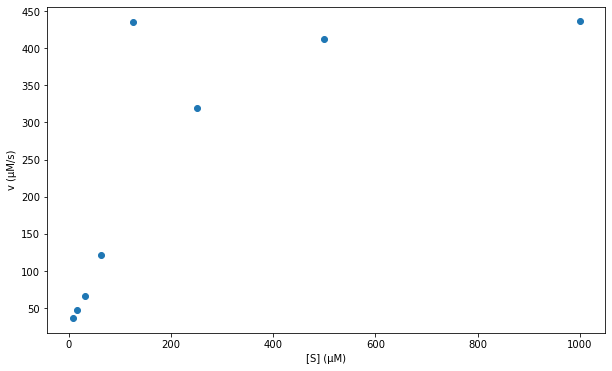

In [48]:
plt.figure(figsize=(10,6))
plt.scatter(sub_concs, np.array(gs_adk_avg_slopes) / e_conc)
plt.xlabel("[S] (µM)")
plt.ylabel("v (µM/s)")